In [1]:
import pandas as pd
import numpy as np
from aeon.visualisation import plot_critical_difference
import matplotlib.pyplot as plt

In [2]:
model_files = {
    "C22-TabPFN": "outputs/C22_rmse.csv",
    "CNN": "outputs/CNN_rmse.csv",
    "DrCIF": "outputs/DrCIF_rmse.csv",
    "FreshPRINCE": "outputs/FreshPRINCE_rmse.csv",
    "InceptionT": "outputs/InceptionT_rmse.csv",
    "MultiROCKET": "outputs/MultiROCKET_rmse.csv",
    "RandF": "outputs/RandF_rmse.csv",
    "ResNet": "outputs/ResNet_rmse.csv",
    "Ridge": "outputs/Ridge_rmse.csv",
    "ROCKET": "outputs/ROCKET_rmse.csv",
    "RotF": "outputs/RotF_rmse.csv",
    "TSF": "outputs/TSF_rmse.csv",
    "XGBoost": "outputs/XGBoost_rmse.csv",
}
metric_name = "RMSE"
lower_better = True

In [3]:
results = {}

for model_name, path in model_files.items():
    
    # Sempre ler com primeira coluna como índice
    df = pd.read_csv(path, index_col=0)

    # Garantir que índice é string
    df.index = df.index.astype(str)

    # Pegar apenas colunas numéricas (folds)
    df = df.select_dtypes(include="number")

    # Média por dataset
    mean_scores = df.mean(axis=1)

    results[model_name] = mean_scores

# Combinar
combined = pd.concat(results, axis=1)

# Remover datasets incompletos
combined = combined.dropna()

In [4]:
combined = pd.DataFrame(results)

# Remover datasets que não estejam presentes em todos
combined = combined.dropna()

print("Datasets usados:", len(combined))

Datasets usados: 58


<Figure size 1000x500 with 0 Axes>

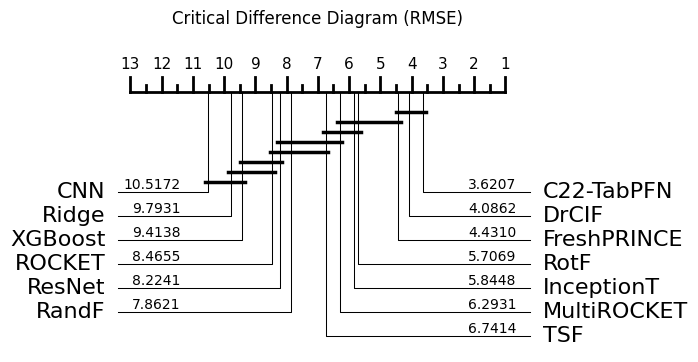

In [5]:
# converter para numpy
scores = combined.to_numpy()

# nomes dos modelos
labels = list(combined.columns)

plt.figure(figsize=(10, 5))

plot_critical_difference(
    scores,
    labels,
    lower_better=True  # RMSE → menor é melhor
)

plt.title(f"Critical Difference Diagram ({metric_name})")
plt.show()